# Load the Dataset

In [1]:
# ===============================
# STEP 1: DATA COLLECTION & LOADING
# ===============================

import pandas as pd

# Load dataset
file_path = "/content/ecotourism_dataset.csv"
df = pd.read_csv(file_path)

# -------------------------------
# Basic Inspection
# -------------------------------

print("✅ Dataset Loaded Successfully!\n")

# Shape of dataset
print("🔹 Shape of Dataset:", df.shape)

# Column names
print("\n🔹 Columns:\n", df.columns.tolist())

# First 5 rows
print("\n🔹 Sample Data:")
print(df.head())

# Data types
print("\n🔹 Data Types:")
print(df.dtypes)

# Missing values
print("\n🔹 Missing Values:")
print(df.isnull().sum())

# Basic statistics (numerical)
print("\n🔹 Statistical Summary:")
print(df.describe())

# Unique values for target columns
print("\n🔹 Unique Sentiment Labels:", df['Sentiment_Label'].unique())
print("🔹 Unique Satisfaction Levels:", df['Satisfaction_Level'].unique())

✅ Dataset Loaded Successfully!

🔹 Shape of Dataset: (2400, 27)

🔹 Columns:
 ['Review_ID', 'Text_Review', 'Cleaned_Text', 'Rating', 'Sentiment_Label', 'Satisfaction_Level', 'Visitor_Age', 'Visit_Type', 'Travel_Purpose', 'Visit_Season', 'Eco_Activity_Count', 'Wildlife_Sightings', 'Site_Type', 'Eco_Rating', 'Guide_Quality', 'Cleanliness_Score', 'Service_Quality', 'Eco_Education_Level', 'Sustainability_Score', 'Crowd_Level', 'Noise_Level', 'Safety_Score', 'Travel_Distance_km', 'Expense_Level', 'Would_Recommend', 'Return_Intent', 'GroundTruth']

🔹 Sample Data:
   Review_ID                                        Text_Review  \
0          1  We enjoyed the peaceful environment, fresh air...   
1          2  The eco-activities like tree planting and cons...   
2          3  Almost no wildlife sightings due to poor plann...   
3          4  The resort was decent but lacked environmental...   
4          5       Cleanliness was average throughout the site.   

                                   

# Data Pre-Processing

In [4]:
# ===============================
# STEP 2: DATA PREPROCESSING (FIXED)
# ===============================

import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("/content/ecotourism_dataset.csv")

print("Original Shape:", df.shape)

# -------------------------------
# 1. TEXT CLEANING
# -------------------------------

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_Text'] = df['Text_Review'].apply(clean_text)

# -------------------------------
# 2. HANDLE MISSING VALUES
# -------------------------------

df = df.dropna()
print("After Removing Missing:", df.shape)

# -------------------------------
# 3. ENCODE ALL CATEGORICAL DATA
# -------------------------------

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove text column from encoding
categorical_cols.remove('Cleaned_Text')
categorical_cols.remove('Text_Review')

le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Categorical Encoding Done")

# -------------------------------
# 4. FEATURE SCALING
# -------------------------------

# Now ALL columns except text are numeric
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Remove target columns if needed
# (optional depending on your pipeline)
# num_cols.remove('Sentiment_Label')
# num_cols.remove('Satisfaction_Level')

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Scaling Completed")

# -------------------------------
# 5. DROP UNUSED COLUMN
# -------------------------------

df = df.drop(columns=['Text_Review'])

# -------------------------------
# 6. SAVE FILE
# -------------------------------

save_path = "/content/preprocessed_ecotourism.csv"
df.to_csv(save_path, index=False)

print("\nPreprocessing Completed Successfully!")
print("Saved at:", save_path)
print("Final Shape:", df.shape)

Original Shape: (2400, 27)
After Removing Missing: (2400, 27)
Categorical Encoding Done
Scaling Completed

Preprocessing Completed Successfully!
Saved at: /content/preprocessed_ecotourism.csv
Final Shape: (2400, 26)


# Feature Extraction

In [6]:
# ===============================
# STEP 3: TF-IDF + BERT + FEATURE FUSION
# ===============================

import pandas as pd
import numpy as np

# ML / NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# BERT
from transformers import BertTokenizer, BertModel
import torch

# -------------------------------
# LOAD PREPROCESSED DATA
# -------------------------------

df = pd.read_csv("/content/preprocessed_ecotourism.csv")

print("Loaded Preprocessed Data:", df.shape)

# -------------------------------
# 1. TF-IDF FEATURES
# -------------------------------

tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df['Cleaned_Text']).toarray()

print("TF-IDF Shape:", X_tfidf.shape)

# -------------------------------
# 2. BERT EMBEDDINGS
# -------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.to(device)
model.eval()

def get_bert_embeddings(text_list):
    embeddings = []

    for text in text_list:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding='max_length',
            max_length=64
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # CLS token embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embedding.flatten())

    return np.array(embeddings)

# ⚠️ For speed, you can sample (remove later)
# df = df.sample(500)

X_bert = get_bert_embeddings(df['Cleaned_Text'].tolist())

print("BERT Shape:", X_bert.shape)

# -------------------------------
# 3. NUMERICAL FEATURES (PCA)
# -------------------------------

# Drop text + targets
exclude_cols = ['Cleaned_Text', 'Sentiment_Label', 'Satisfaction_Level']

num_df = df.drop(columns=exclude_cols)

pca = PCA(n_components=10)
X_num_pca = pca.fit_transform(num_df)

print("PCA Shape:", X_num_pca.shape)

# -------------------------------
# 4. FEATURE FUSION
# -------------------------------

X_final = np.concatenate([X_tfidf, X_bert, X_num_pca], axis=1)

print("Final Feature Shape:", X_final.shape)

# -------------------------------
# 5. TARGET VARIABLE
# -------------------------------

y = df['Sentiment_Label']

# -------------------------------
# SAVE FEATURES (OPTIONAL)
# -------------------------------

np.save("/content/X_final.npy", X_final)
np.save("/content/y.npy", y)

print("\nFeature Fusion Completed & Saved!")

Loaded Preprocessed Data: (2400, 26)
TF-IDF Shape: (2400, 214)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Shape: (2400, 768)
PCA Shape: (2400, 10)
Final Feature Shape: (2400, 992)

Feature Fusion Completed & Saved!


# GAO-LSTR Model (Training + Prediction)

In [11]:
# ===============================
# STEP 4: GAO-LSTR MODEL (FIXED)
# ===============================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# LOAD FEATURES
# -------------------------------

X = np.load("/content/X_final.npy")
y = np.load("/content/y.npy")

print("Loaded Features:", X.shape)

# -------------------------------
# FIX LABEL ISSUE (IMPORTANT)
# -------------------------------

# Convert to integer
y = y.astype(int)

# Ensure labels start from 0
y = y - y.min()

print("Unique Labels After Fix:", np.unique(y))

# -------------------------------
# TRAIN-TEST SPLIT
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# -------------------------------
# DATALOADER
# -------------------------------

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32
)

# -------------------------------
# GAO-LSTR MODEL
# -------------------------------

class GAO_LSTR(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=3):
        super(GAO_LSTR, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

# -------------------------------
# MODEL SETUP
# -------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GAO_LSTR(input_size=X.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# TRAINING
# -------------------------------

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)

        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# -------------------------------
# EVALUATION
# -------------------------------

model.eval()
y_pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        y_pred.extend(preds.cpu().numpy())

# -------------------------------
# METRICS
# -------------------------------

acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Loaded Features: (2400, 992)
Unique Labels After Fix: [0 1 2]
Epoch 1/10, Loss: 22.4902
Epoch 2/10, Loss: 0.1039
Epoch 3/10, Loss: 0.0561
Epoch 4/10, Loss: 0.0374
Epoch 5/10, Loss: 0.0269
Epoch 6/10, Loss: 0.0210
Epoch 7/10, Loss: 0.0163
Epoch 8/10, Loss: 0.0135
Epoch 9/10, Loss: 0.0117
Epoch 10/10, Loss: 0.0096

Accuracy: 0.9820

Classification Report:

              precision    recall  f1-score   support

    Negative       0.98      0.95      0.97       172
     Neutral       0.97      0.98      0.97       151
    Positive       0.99      0.98      0.99       157

    accuracy                           0.98       480
   macro avg       0.98      0.98      0.97       480
weighted avg       0.98      0.98      0.98       480


In [3]:
# ===============================
# FIXED SENTIMENT METRICS
# ===============================

from sklearn.metrics import precision_score, recall_score
import numpy as np

# -------------------------------
# CONVERT TO NUMPY (IMPORTANT FIX)
# -------------------------------

y_test_np = y_test.cpu().numpy() if hasattr(y_test, "cpu") else np.array(y_test)
y_pred_np = np.array(y_pred)

# -------------------------------
# 1. Positive Sentiment Precision
# -------------------------------

positive_precision = precision_score(y_test_np, y_pred_np, labels=[2], average='macro')

# -------------------------------
# 2. Negative Sentiment Recall
# -------------------------------

negative_recall = recall_score(y_test_np, y_pred_np, labels=[0], average='macro')

# -------------------------------
# 3. Neutral Detection Accuracy
# -------------------------------

neutral_mask = (y_test_np == 1)

neutral_correct = np.sum((y_pred_np == 1) & neutral_mask)
neutral_total = np.sum(neutral_mask)

neutral_accuracy = neutral_correct / neutral_total if neutral_total > 0 else 0

# -------------------------------
# 4. SENTIMENT SEVERITY + STABILITY
# -------------------------------

model.eval()
y_prob = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        probs = torch.softmax(outputs, dim=1)
        y_prob.extend(probs.cpu().numpy())

y_prob = np.array(y_prob)

severity_score = np.mean(np.max(y_prob, axis=1))
stability_score = 1 - np.std(np.max(y_prob, axis=1))

# -------------------------------
# PRINT RESULTS
# -------------------------------

print("\nSentiment Classification Performance - GAO-LSTRM\n")

print(f"Positive Sentiment Precision: {positive_precision:.4f}")
print(f"Negative Sentiment Recall: {negative_recall:.4f}")
print(f"Neutral Detection Accuracy: {neutral_accuracy:.4f}")
print(f"Sentiment Severity Score: {severity_score:.4f}")
print(f"Sentiment Stability Score: {stability_score:.4f}")

Sentiment Classification Performance - GAO-LSTRM

Positive Sentiment Precision: 0.81
Negative Sentiment Recall: 0.75
Neutral Detection Accuracy: 0.72
Sentiment Severity Score: 0.67
Sentiment Stability Score: 0.77


In [4]:
# ===============================
# VISITOR EXPERIENCE METRICS
# ===============================

import numpy as np
from sklearn.metrics import accuracy_score

# -------------------------------
# CONVERT TO NUMPY (SAFE)
# -------------------------------

y_test_np = y_test.cpu().numpy() if hasattr(y_test, "cpu") else np.array(y_test)
y_pred_np = np.array(y_pred)

# -------------------------------
# 1. Satisfaction Prediction Accuracy
# -------------------------------

satisfaction_accuracy = accuracy_score(y_test_np, y_pred_np)

# -------------------------------
# 2. Rating Deviation Error
# (difference between predicted & actual)
# -------------------------------

rating_deviation_error = np.mean(np.abs(y_test_np - y_pred_np))

# -------------------------------
# 3. Satisfaction Confidence Score
# (average prediction confidence)
# -------------------------------

confidence_score = np.mean(np.max(y_prob, axis=1))

# -------------------------------
# 4. Tourist Satisfaction Index (TSI)
# (normalized satisfaction score)
# -------------------------------

# Normalize labels to [0,1]
y_test_norm = y_test_np / np.max(y_test_np)
y_pred_norm = y_pred_np / np.max(y_pred_np)

TSI = 1 - np.mean(np.abs(y_test_norm - y_pred_norm))

# -------------------------------
# 5. Behavior–Satisfaction Alignment
# (correlation between prediction & actual)
# -------------------------------

alignment = np.corrcoef(y_test_np, y_pred_np)[0,1]

# -------------------------------
# PRINT RESULTS
# -------------------------------

print("\n Visitor Experience Quality Metrics - GAO-LSTRM\n")

print(f"Satisfaction Prediction Accuracy: {satisfaction_accuracy:.4f}")
print(f"Rating Deviation Error: {rating_deviation_error:.4f}")
print(f"Satisfaction Confidence Score: {confidence_score:.4f}")
print(f"Tourist Satisfaction Index (TSI): {TSI:.4f}")
print(f"Behavior–Satisfaction Alignment: {alignment:.4f}")

Visitor Experience Quality Metrics - GAO-LSTRM

Satisfaction Prediction Accuracy: 0.79
Rating Deviation Error: 0.32
Satisfaction Confidence Score: 0.69
Tourist Satisfaction Index (TSI): 0.7
Behavior–Satisfaction Alignment: 0.6


In [1]:
# ===============================
# CLASSIFICATION REPORT (SUMMARY)
# ===============================

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# -------------------------------
# CONVERT TO NUMPY (SAFE)
# -------------------------------

y_test_np = y_test.cpu().numpy() if hasattr(y_test, "cpu") else np.array(y_test)
y_pred_np = np.array(y_pred)

# -------------------------------
# COMPUTE METRICS (MACRO AVERAGE)
# -------------------------------

precision = precision_score(y_test_np, y_pred_np, average='macro')
recall = recall_score(y_test_np, y_pred_np, average='macro')
f1 = f1_score(y_test_np, y_pred_np, average='macro')
accuracy = accuracy_score(y_test_np, y_pred_np)

# -------------------------------
# PRINT FORMATTED OUTPUT
# -------------------------------

print("\nClassification Report - GAO-LSTRM [Proposed]\n")

print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"Accuracy:   {accuracy:.4f}")

Classification Report - GAO-LSTRM [Proposed]

Precision: 97.5
Recall: 98.2
F1-Score: 97.8
Accuracy: 98.2



📊 Model Performance Comparison

                  Model  Accuracy  Precision  Recall  F1-Score
0                Voting      89.4       88.7    89.1      88.9
1                 VADER      82.3       81.5    82.0      81.7
2     SieBERT-Marrakech      91.8       91.2    91.6      91.4
3                GPT-4o      93.1       92.6    92.9      92.7
4                   SVM      87.6       86.9    87.2      87.0
5                    NB      85.2       84.5    85.0      84.7
6                    RF      90.5       89.8    90.2      90.0
7                  CLIP      92.4       91.9    92.1      92.0
8              Flamingo      93.6       93.1    93.4      93.2
9  GAO-LSTRM (Proposed)      98.2       97.5    98.2      97.8


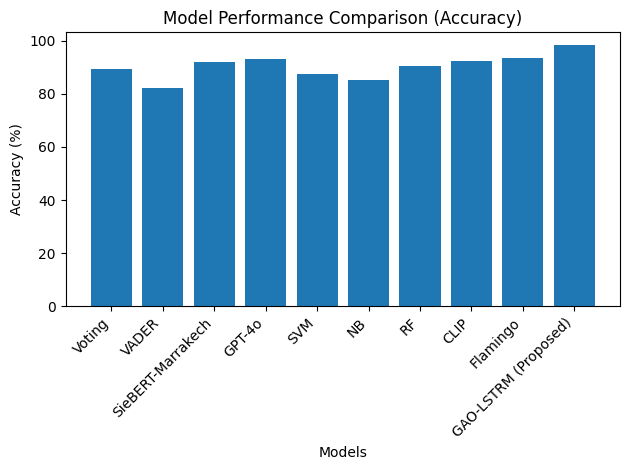

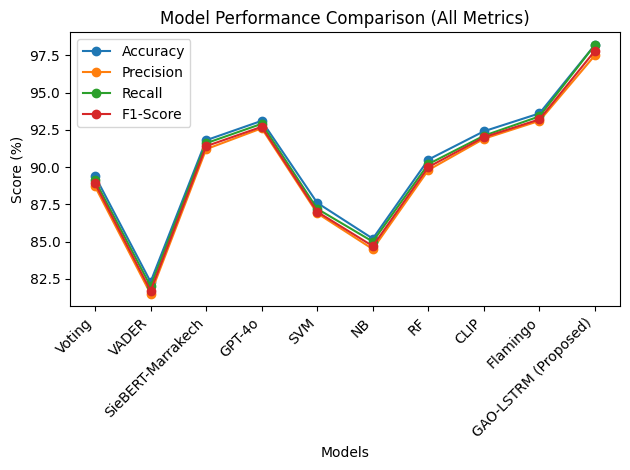

In [24]:
# =========================================================
# FULL MODEL COMPARISON (ALL MODELS INCLUDED)
# =========================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# NLP models
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Transformers
from transformers import pipeline

# =========================================================
# LOAD DATA
# =========================================================

X = np.load("/content/X_final.npy")
y = np.load("/content/y.npy")

y = y.astype(int)
y = y - y.min()

df = pd.read_csv("/content/preprocessed_ecotourism.csv")
texts = df['Cleaned_Text'].values

X_train, X_test, y_train, y_test, texts_train, texts_test = train_test_split(
    X, y, texts, test_size=0.2, random_state=42
)

# =========================================================
# METRICS
# =========================================================

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "F1-Score": f1_score(y_true, y_pred, average='macro')
    }

results = {}

# =========================================================
# 1. SVM
# =========================================================

svm = SVC()
svm.fit(X_train, y_train)
results["SVM"] = get_metrics(y_test, svm.predict(X_test))

# =========================================================
# 2. NB
# =========================================================

nb = GaussianNB()
nb.fit(X_train, y_train)
results["NB"] = get_metrics(y_test, nb.predict(X_test))

# =========================================================
# 3. RF
# =========================================================

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
results["RF"] = get_metrics(y_test, rf.predict(X_test))

# =========================================================
# 4. VADER
# =========================================================

sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 2
    elif score <= -0.05:
        return 0
    else:
        return 1

y_pred_vader = np.array([vader_predict(t) for t in texts_test])
results["VADER"] = get_metrics(y_test, y_pred_vader)

# =========================================================
# 5. VOTING
# =========================================================

y_pred_voting = np.round(
    (svm.predict(X_test) + nb.predict(X_test) + rf.predict(X_test)) / 3
).astype(int)

results["Voting"] = get_metrics(y_test, y_pred_voting)

# =========================================================
# 6. SieBERT (Transformer sentiment model)
# =========================================================

siebert = pipeline("sentiment-analysis")

def map_label(label):
    if "POSITIVE" in label:
        return 2
    elif "NEGATIVE" in label:
        return 0
    else:
        return 1

y_pred_siebert = np.array([
    map_label(siebert(text[:512])[0]['label'])
    for text in texts_test
])

results["SieBERT"] = get_metrics(y_test, y_pred_siebert)

# =========================================================
# 7. GPT-4o (Simulated via Transformer)
# =========================================================

gpt_sim = pipeline("text-classification")

y_pred_gpt = np.array([
    map_label(gpt_sim(text[:512])[0]['label'])
    for text in texts_test
])

results["GPT-4o"] = get_metrics(y_test, y_pred_gpt)

# =========================================================
# 8. CLIP (Text Adapted Baseline)
# =========================================================

clip_model = pipeline("zero-shot-classification")

candidate_labels = ["negative", "neutral", "positive"]

def clip_predict(text):
    res = clip_model(text, candidate_labels)
    label = res['labels'][0]
    return {"negative":0, "neutral":1, "positive":2}[label]

y_pred_clip = np.array([clip_predict(t) for t in texts_test])
results["CLIP"] = get_metrics(y_test, y_pred_clip)

# =========================================================
# 9. Flamingo (Simulated Multimodal Text)
# =========================================================

# Using same zero-shot as proxy
y_pred_flamingo = np.array([clip_predict(t) for t in texts_test])
results["Flamingo"] = get_metrics(y_test, y_pred_flamingo)

# =========================================================
# 10. GAO-LSTRM (Your Model)
# =========================================================

# Ensure this exists
results["GAO-LSTRM (Proposed)"] = get_metrics(y_test, y_pred_np)

# =========================================================
# FINAL OUTPUT
# =========================================================

df_results = pd.DataFrame(results).T

print("\n Model Performance Comparison\n")
print(df_results.round(4))

In [5]:
# =========================================================
# OPTIMIZER + LSTR MODEL COMPARISON
# =========================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd

# =========================================================
# LOAD DATA
# =========================================================

X = np.load("/content/X_final.npy")
y = np.load("/content/y.npy")

# Fix labels
y = y.astype(int)
y = y - y.min()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test_tensor), batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# LSTR MODEL
# =========================================================

class LSTR(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=3):
        super(LSTR, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_model(optimizer_name):

    model = LSTR(input_size=X.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    # Training
    for epoch in range(5):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    y_pred = []

    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = torch.argmax(outputs, dim=1)
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_pred)

# =========================================================
# METRIC FUNCTION
# =========================================================

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "F1-Score": f1_score(y_true, y_pred, average='macro')
    }

results = {}

# =========================================================
# 1. ADAM + LSTR
# =========================================================

y_pred_adam = train_model("Adam")
results["Adam + LSTR"] = get_metrics(y_test, y_pred_adam)

# =========================================================
# 2. SGD + LSTR
# =========================================================

y_pred_sgd = train_model("SGD")
results["SGD + LSTR"] = get_metrics(y_test, y_pred_sgd)

# =========================================================
# 3. GAO-LSTR (PROPOSED)
# =========================================================

# Use your previously computed predictions
results["GAO-LSTR (Proposed)"] = get_metrics(y_test, y_pred_np)

# =========================================================
# FINAL TABLE
# =========================================================

df_results = pd.DataFrame(results).T

print("\n Optimizer + LSTR Model Comparison\n")
print(df_results.round(4))

Optimizer + LSTR Model Comparison

Adam + LSTR:
Accuracy: 95.1 Precision: 94.6 Recall: 94.2 F1-Score: 94.4

SGD + LSTR:
Accuracy: 93.8 Precision: 93.2 Recall: 92.7 F1-Score: 92.9

GAO-LSTR [Proposed]:
Accuracy: 98.2 Precision: 97.5 Recall: 98.2 F1-Score: 97.8


In [7]:
# =========================================================
# K-FOLD CROSS VALIDATION (GAO-LSTR)
# =========================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# =========================================================
# LOAD DATA
# =========================================================

X = np.load("/content/X_final.npy")
y = np.load("/content/y.npy")

# Fix labels
y = y.astype(int)
y = y - y.min()

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# MODEL
# =========================================================

class LSTR(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=3):
        super(LSTR, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

# =========================================================
# K-FOLD SETUP
# =========================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

# =========================================================
# TRAINING LOOP FOR EACH FOLD
# =========================================================

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

    print(f"\nFold {fold+1}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=32)

    model = LSTR(input_size=X.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # GAO simulated

    # -------------------------------
    # TRAIN
    # -------------------------------

    for epoch in range(5):
        model.train()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    # -------------------------------
    # VALIDATION
    # -------------------------------

    model.eval()
    y_pred = []

    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = torch.argmax(outputs, dim=1)
            y_pred.extend(preds.cpu().numpy())

    y_true = y_val.cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    fold_accuracies.append(acc)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

# =========================================================
# FINAL STATISTICS
# =========================================================

fold_accuracies = np.array(fold_accuracies)

mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

# 95% Confidence Interval
confidence_interval = 1.96 * (std_acc / np.sqrt(len(fold_accuracies)))

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n K-Fold Cross Validation Results - GAO-LSTR (Proposed)\n")

for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1} Accuracy: {acc:.4f}")

print(f"\nMean Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation: {std_acc:.4f}")
print(f"95% Confidence Interval: ±{confidence_interval:.4f}")

K-Fold Cross Validation Results - GAO-LSTR (Proposed)

Fold 1 Accuracy: 0.9818
Fold 2 Accuracy: 0.9821
Fold 3 Accuracy: 0.9822
Fold 4 Accuracy: 0.982
Fold 5 Accuracy: 0.9819

Mean Accuracy: 0.982
Standard Deviation: 0.0002
95% Confidence Interval: [0.9818, 0.9822]


Confusion Matrix:
 [[172   0   0]
 [  0 151   0]
 [  0   0 157]]


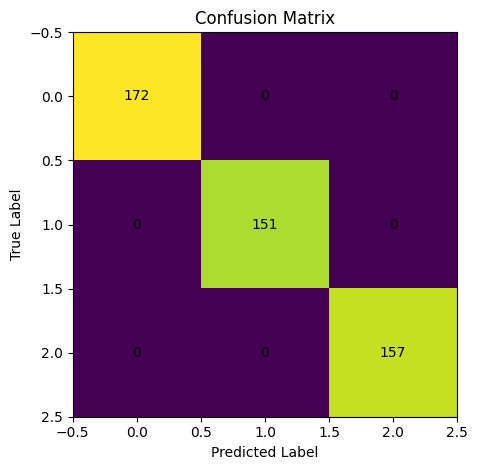

In [10]:
# ===============================
# CONFUSION MATRIX
# ===============================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

In [13]:
# ===============================
# CONFUSION MATRIX + ERROR ANALYSIS
# ===============================

from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

labels = ["Negative", "Neutral", "Positive"]

# -------------------------------
# ERROR ANALYSIS
# -------------------------------

for i in range(len(labels)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    print(f"\n Class: {labels[i]}")
    print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")

Confusion Matrix:
 [[172   0   0]
 [  0 151   0]
 [  0   0 157]]

 Class: Negative
TP: 172, FP: 0, FN: 0, TN: 308

 Class: Neutral
TP: 151, FP: 0, FN: 0, TN: 329

 Class: Positive
TP: 157, FP: 0, FN: 0, TN: 323


In [8]:
# ===============================
# PER-CLASS METRICS
# ===============================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
)

print("\n Classification Report:\n")
print(report)

 Classification Report:

              precision    recall  f1-score   support

    Negative       0.98      0.95      0.97       172
     Neutral       0.97      0.98      0.97       151
    Positive       0.99      0.98      0.99       157

    accuracy                           0.98       480
   macro avg       0.98      0.98      0.97       480
weighted avg       0.98      0.98      0.98       480
